# Basic Sand-Bob usage: Code generation
For getting started with Sand-Bob, you first should initialize the LLM server you want to use. In this example, we have [ollama](https://ollama.com) locally installed and can use it like this:

In [1]:
from sand_bob import generate_code, config_llms

config_llms(model="gemma3:4b",
            base_url="http://localhost:11434/v1",
            api_key="none"
           )

You can then generate (and execute) code like this:

In [2]:
result = generate_code("print out the numbers between 0 and 9", final_touch=False)

The result can be inspected in an interactive GUI (which will not render on github.com, you need to execute this notebook to see it).

In [3]:
result

ExecutionResult(stdout='[jupytext] Reading notebook.mystnb in format mystnb\n[jupytext] Writing notebook.ipynb\n[NbConvertApp] Converting notebook notebook.ipynb to notebook\n[NbConvertApp] Writing 1279 bytes to /display_output/notebook_executed.ipynb\n', stderr='', exit_code=0, execution_time=4.231765985488892, run_time=3.4414453506469727, build_time=0.7343723773956299, container_id='35e55b19ba17ef0298e0864f91886ff23e0aa6d9606a41fafeeecf87168c8f19', prompt='\nYou are an expert in python programming. You have a list of framework constraints which you MUST follow.\nYour task is to generate a fully functional code snippet that will be used to fulfill the prompt.\nAssume your code will be executed in a Jupyter notebook cell.\n\n# Framework constraints\n* You may use the following libraries, but only if necessary: \n* pip install is STRICTLY PROHIBITED. You can only use the libraries mentioned above.\n* Statistics: When applying statisticals test, ENSURE that pre-conditions for the tests are checked before the tests are performed.\n* Final result output (print or display calls): \n  * The second-last print or display call should be a description of the result (e.g. the measurment and a physical unit if relevant).\n  * The last print or display call should be the final result ONLY.\n  * If the task is to generate a count, ratio or measurements, print the final result using a separate `print` call. \n  * If the task is to answer a yes/no question, print "Yes" or "No" using a separate `print` call. Do not create any JSON for this.\n  * If the task is to generate a plot, display the plot.\n  * Also plot intermediate results if possible.\n* Final result output (file writing):\n  * If the task is to generate a text or a string, write the text or string to "/display_output/final_result.txt".\n  * If the task is to generate a table, write the table to "/display_output/final_result.csv".\n  * If the task is to generate a number, list, array or dictionary, write the result to "/display_output/final_result.json".\n    In that case, do not add additional data structures. Simply json.dump the result to the file. E.g. if the result is x=2, then just do `json.dump(x, fp)`.\n* Keep the code short and concise.\n\n\nprint out the numbers between 0 and 9', code='# Print numbers from 0 to 9\nfor i in range(10):\n    print(i)\nprint("Numbers from 0 to 9 have been printed.")', dependencies=[], traceback=None, files={'/display_output/notebook_executed.ipynb': b'{\n "cells": [\n  {\n   "cell_type": "code",\n   "execution_count": 1,\n   "id": "53edd5cd",\n   "metadata": {\n    "execution": {\n     "iopub.execute_input": "2026-05-23T09:01:26.318765Z",\n     "iopub.status.busy": "2026-05-23T09:01:26.318659Z",\n     "iopub.status.idle": "2026-05-23T09:01:26.323460Z",\n     "shell.execute_reply": "2026-05-23T09:01:26.322857Z"\n    }\n   },\n   "outputs": [\n    {\n     "name": "stdout",\n     "output_type": "stream",\n     "text": [\n      "0\\n",\n      "1\\n",\n      "2\\n",\n      "3\\n",\n      "4\\n",\n      "5\\n",\n      "6\\n",\n      "7\\n",\n      "8\\n",\n      "9\\n",\n      "Numbers from 0 to 9 have been printed.\\n"\n     ]\n    }\n   ],\n   "source": [\n    "# Print numbers from 0 to 9\\n",\n    "for i in range(10):\\n",\n    "    print(i)\\n",\n    "print(\\"Numbers from 0 to 9 have been printed.\\")"\n   ]\n  }\n ],\n "metadata": {\n  "jupytext": {\n   "default_lexer": "ipython3"\n  },\n  "kernelspec": {\n   "display_name": "python3",\n   "name": "python3"\n  },\n  "language_info": {\n   "codemirror_mode": {\n    "name": "ipython",\n    "version": 3\n   },\n   "file_extension": ".py",\n   "mimetype": "text/x-python",\n   "name": "python",\n   "nbconvert_exporter": "python",\n   "pygments_lexer": "ipython3",\n   "version": "3.11.14"\n  }\n },\n "nbformat": 4,\n "nbformat_minor": 5\n}\n'}, n_codefix_attempts=1, outputs=[{'type': 'text/plain', 'data': '0\n1\n2\n3\n4\n5\n6\n7\n8\n9\nNumbers from 0 to 9 have been printed.'}], feedback='Overall the

You can also just visualize the output of the generated code.

In [4]:
result.display_output()

And you can print out the generated code itself:

In [5]:
print(result.code)

# Print numbers from 0 to 9
for i in range(10):
    print(i)
print("Numbers from 0 to 9 have been printed.")


## Working with files
You can also do this involving files and image output, e.g. like this:


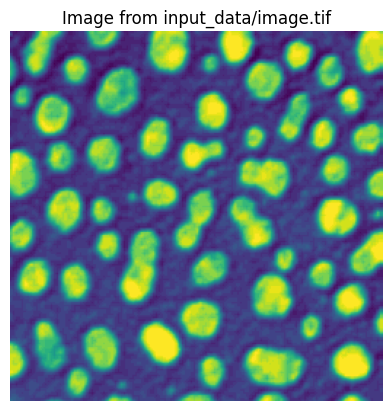

In [6]:
result = generate_code("Load input_data/image.tif and show it", 
                       input_host_path="input_data", 
                       dependencies=["scikit-image", "matplotlib"], 
                       final_touch=False)
result.display_output()

In [7]:
print(result.code)

import skimage.io
import matplotlib.pyplot as plt

# Load the image
image = skimage.io.imread('input_data/image.tif')

# Display the image
plt.imshow(image)
plt.title('Image from input_data/image.tif')  # Add a title
plt.axis('off')  # Hide axis
plt.show()

# Print the result
print("Image displayed successfully.")
